# Notebook 2C — Tuning a Neural Network

*Day 4 · Student C's tuning lab — read the docstring, choose knobs, search, log, and save your MLP.*

In [1]:
# ======================================================================================
# Setup — run this first (you don't need to read it closely).
# It imports a few libraries, sets a shared plot style, and defines the helper functions used
# throughout the notebook (load_data, the plot helpers, the metric helpers, ...).  These are the
# SAME helpers in every notebook, so your results line up with your teammates'.  If a later cell
# says a helper is "not defined", you probably skipped this cell — run it, then carry on.
# ======================================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sbi import analysis
from sbi.neural_nets import posterior_nn
from sbi.inference import NPE
from sbi.utils import BoxUniform
from sklearn.decomposition import PCA


# ----------------------------------------------------------------------------------------
# Paths — resolved so the notebooks work whether they're run from the materials folder or
# from solutions/ .  Outputs and figures always land in the materials root.
# ----------------------------------------------------------------------------------------
def _materials_root():
    """Folder that contains data/ ; searched upward from the working directory."""
    here = os.path.abspath(os.getcwd())
    for d in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        if os.path.isdir(os.path.join(d, "data")):
            return d
    return here

ROOT = _materials_root()
DATA_DIR = os.path.join(ROOT, "data")
OUTPUTS_DIR = os.path.join(ROOT, "outputs")
FIGURES_DIR = os.path.join(ROOT, "figures")
MODELS_DIR = os.path.join(ROOT, "models")     # fitted models saved to disk (experiment tracking)
for _d in (DATA_DIR, OUTPUTS_DIR, FIGURES_DIR, MODELS_DIR):
    os.makedirs(_d, exist_ok=True)

# Module-level cache of the reconstruction basis (set by load_data; used by reconstruct_spectrum).
_RECON = {"wavelength": None, "basis": None, "is_mock": True, "Xerr": None}
_RAW_CACHE = {}   # path -> full arrays, so repeated load_data() calls don't re-read the file

# Default working-set size.  The real catalog is ~263k stars; we train on a fast deterministic
# subsample by default so in-class fits stay quick AND every notebook sees the SAME stars (which
# keeps the NB2->NB3->NB4 saved-prediction hand-off aligned).  Pass n=None to use the WHOLE
# high-quality catalog (the "does more data help?" / label-transfer-at-scale exercise).
DEFAULT_N = 30000

# Canonical label columns.  The modelling track predicts [Fe/H]; Teff & logg are explored and
# used as the axes for residual / coverage maps.  alpha/age/dist are extra "explore" labels.
LABEL_COLS = ["Teff", "logg", "FeH", "alpha", "age", "dist"]
PRETTY = {"Teff": r"$T_\mathrm{eff}$ [K]", "logg": r"$\log g$ [dex]",
          "FeH": r"[Fe/H] [dex]", "alpha": r"[$\alpha$/M] [dex]",
          "age": "age [Gyr]", "dist": "distance [pc]"}


# ========================================================================================
# Plot style
# ========================================================================================
def set_plot_style():
    """Consistent, readable matplotlib defaults.  Called once in setup."""
    plt.rcParams.update({
        "figure.figsize": (6.4, 4.4), "figure.dpi": 110, "savefig.dpi": 150,
        "savefig.bbox": "tight", "font.size": 12, "axes.titlesize": 13,
        "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.25,
        "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
        "legend.frameon": False, "legend.fontsize": 11, "lines.linewidth": 2.0,
        "scatter.edgecolors": "none", "image.cmap": "viridis",
    })

# A small colour-blind-friendly palette used across the materials for named series.
COLORS = {"linear": "#888888", "knn": "#0072B2", "rf": "#009E73",
          "nn": "#D55E00", "native": "#0072B2", "conformal": "#D55E00",
          "truth": "#222222", "accent": "#CC79A7"}


# ========================================================================================
# Data loading  (the mock generator lives here so the shipped npz and the on-the-fly
# fallback are guaranteed identical)
# ========================================================================================
_C2_NM = 1.438777e7  # second radiation constant hc/k in nm*K


def _build_basis(wave_min=336.0, wave_max=1020.0, n_wave=343, n_bp=55, n_rp=55):
    """Smooth windowed-cosine modes per band, orthonormalised.  Low modes are broad
    (continuum), high modes wiggly (fine structure).  reconstruct = B @ coeff."""
    wave = np.linspace(wave_min, wave_max, n_wave)
    cols = []
    def band(lo, hi, n_modes):
        x = (wave - lo) / (hi - lo)
        win = np.where((x >= 0) & (x <= 1), np.sin(np.clip(x, 0, 1) * np.pi) ** 0.5, 0.0)
        for j in range(n_modes):
            cols.append(np.cos(j * np.pi * np.clip(x, 0, 1)) * win)
    band(wave_min, 690.0, n_bp)
    band(630.0, wave_max, n_rp)
    Q, _ = np.linalg.qr(np.column_stack(cols))
    return wave, Q[:, :n_bp + n_rp]


def _synthesize_mock(n=50000, seed=42):
    """
    # MOCK DATA — swap for the real Zenodo loader.
    Physically-motivated synthetic stand-in for the Laroche & Speagle APOGEE x Gaia-XP
    cross-match.  Returns the same dict that the shipped npz stores.  See the build spec
    and _build/make_mock_dataset.py for the full rationale.  In one sentence: a Planck
    continuum sets Teff; Balmer lines reinforce Teff; gravity-sensitive molecular bands
    carry log g; SHALLOW metal lines (suppressed at high Teff) carry the hard, heteroscedastic
    [Fe/H]; reddening + hidden factors add a realistic irreducible (aleatoric) floor.
    """
    rng = np.random.default_rng(seed)
    wave, B = _build_basis()
    W = wave.size

    # --- labels with Kiel-diagram structure: dwarfs + giants + red clump + metal-poor halo ---
    is_giant = rng.random(n) < 0.45
    Teff = np.empty(n); logg = np.empty(n); FeH = np.empty(n)
    nd, ng = np.count_nonzero(~is_giant), np.count_nonzero(is_giant)
    Td = 4000 + 3100 * rng.beta(1.5, 2.5, nd)
    Teff[~is_giant] = Td
    logg[~is_giant] = 4.62 - 0.00013 * (Td - 4500) + rng.normal(0, 0.10, nd)
    FeH[~is_giant] = rng.normal(-0.05, 0.25, nd)
    Tg = 3800 + 1700 * rng.beta(2.0, 2.3, ng)
    Teff[is_giant] = Tg
    logg[is_giant] = 1.7 + 0.00095 * (Tg - 3800) + rng.normal(0, 0.33, ng)
    FeH[is_giant] = rng.normal(-0.28, 0.34, ng)
    clump = is_giant & (rng.random(n) < 0.33); nc = np.count_nonzero(clump)
    Teff[clump] = rng.normal(4800, 140, nc); logg[clump] = rng.normal(2.45, 0.11, nc)
    FeH[clump] = rng.normal(-0.10, 0.20, nc)
    halo = rng.random(n) < 0.06; nh = np.count_nonzero(halo)
    Teff[halo] = rng.normal(4900, 450, nh)
    logg[halo] = np.clip(rng.normal(2.2, 0.7, nh), 0.5, 3.6)
    FeH[halo] = rng.normal(-1.45, 0.45, nh)
    is_giant = is_giant | halo
    Teff = np.clip(Teff, 3500, 7600); logg = np.clip(logg, 0.3, 5.0); FeH = np.clip(FeH, -2.4, 0.55)
    alpha = np.clip(0.13 - 0.24 * FeH + rng.normal(0, 0.035, n), -0.05, 0.5)
    age = np.clip(2.0 + 6.5 * is_giant - 3.5 * FeH + rng.normal(0, 1.8, n), 0.3, 13.5)
    dist = np.exp(rng.normal(6.7, 0.9, n)) * (1.0 + 1.5 * is_giant)

    # --- forward model: labels -> flux ---
    def gauss(c, w): return np.exp(-0.5 * ((wave - c) / w) ** 2)
    x = _C2_NM / (wave[None, :] * Teff[:, None])
    flux = wave[None, :] ** -5 / np.expm1(np.clip(x, 1e-6, 700))
    flux = flux / flux.mean(axis=1, keepdims=True)
    jump = 1.0 / (1.0 + np.exp((wave - 382.0) / 6.0))
    flux *= 1.0 - (0.18 * np.clip((Teff - 5200) / 2500, 0, 1.4) * (1 + 0.15 * (4.5 - logg)))[:, None] * jump[None, :]
    balmer = sum(a * gauss(c, 9.0) for c, a in [(434., .9), (486.1, 1.1), (656.3, 1.)])
    bstr = np.clip(np.exp((Teff - 5200) / 1500), 0.15, 6.0) * (1 + 0.12 * (4.5 - logg))
    flux *= 1.0 - 0.012 * bstr[:, None] * balmer[None, :]
    g_dwarf = np.clip(logg - 3.0, 0, 2.0)[:, None]; g_giant = np.clip(3.6 - logg, 0, 3.2)[:, None]
    coolf = np.clip((5500 - Teff) / 2000.0, 0.2, 1.4)[:, None]
    grav = np.zeros((n, W))
    for c, a in [(488., 1.), (521., .9), (692., .8)]: grav += a * g_dwarf * gauss(c, 15.)[None, :]
    for c, a in [(421., .9), (793., .8), (883., 1.)]: grav += a * g_giant * gauss(c, 17.)[None, :]
    flux *= 1.0 - 0.038 * coolf * grav
    metal = sum(a * gauss(c, 11.0) for c, a in
                [(422.7, 1.), (460., .7), (517.3, 1.2), (527., .9), (589.3, 1.1),
                 (670.8, .6), (770., .6), (850., .8), (920., .5)])
    # Line depth scales with metal abundance (metal-poor stars have WEAK lines -> little [Fe/H]
    # information -> the dominant, physically-correct source of heteroscedastic [Fe/H] error).
    # Temperature only mildly suppresses lines; gravity gives luminous giants slightly weaker,
    # more variable lines (they are also the sparsest, most-extrapolated regime).
    mstr = 10.0 ** (0.55 * FeH)
    tsupp = np.clip(np.exp(-(Teff - 4500) / 4800.0), 0.6, 1.25)
    line_amp = (mstr * tsupp * np.clip(0.7 + 0.22 * logg, 0.7, 1.4))[:, None]
    flux *= 1.0 - 0.045 * line_amp * metal[None, :]
    ebv = np.abs(rng.normal(0, 0.11, n))[:, None]
    ext = (550.0 / wave) ** 1.0
    flux *= 10.0 ** (-0.4 * 1.6 * ebv * (ext / ext.mean())[None, :])
    P = np.column_stack([np.sin(f * np.pi * (wave - wave[0]) / (wave[-1] - wave[0])) for f in (1.5, 3.5, 6.5)])
    flux *= 1.0 + 0.004 * (rng.normal(0, 1, (n, 3)) @ P.T)
    gflux = np.exp(rng.normal(0.0, 0.8, n))
    snr = np.clip(58 * gflux ** 0.30 * np.exp(rng.normal(0, 0.30, n)), 20, 400)
    obs = gflux[:, None] * np.clip(flux, 1e-3, None)
    noise_std = obs.mean(axis=1, keepdims=True) / snr[:, None]        # photon-noise std (per star)
    obs = obs + rng.normal(0, 1, obs.shape) * noise_std
    X = (obs @ B).astype(np.float32)
    # per-coefficient measurement error on the RAW coefficients (the orthonormal basis preserves the
    # per-component noise std) — used by the NB3 input-Monte-Carlo stretch.
    Xerr = np.repeat(noise_std, 110, axis=1).astype(np.float32)
    return dict(X=X, Xerr=Xerr, Teff=Teff, logg=logg, FeH=FeH, alpha=alpha, age=age, dist=dist,
                snr=snr, gflux=gflux, source_id=(1_000_000_000 + np.arange(n)),
                wavelength=wave, basis=B.astype(np.float32), is_mock=True)


def load_data(path=None, n=DEFAULT_N, seed=0, verbose=True):
    """
    Load the dataset in one line:  X, y, meta = load_data()

    Parameters
    ----------
    n    : working-set size.  Returns a deterministic random subsample of `n` stars (default
           DEFAULT_N=30000) so fits are fast and every notebook sees the same stars.  Pass
           `n=None` to use the ENTIRE high-quality catalog (the scale-up exercise) — slower.
    seed : seed for the subsample (keep it fixed so the NB2->NB3->NB4 hand-off stays aligned).

    Returns
    -------
    X    : float array, shape (n, 110) — the Gaia XP coefficients (55 BP + 55 RP).
    y    : DataFrame with columns Teff, logg, FeH (+ alpha, dist) — the labels.
    meta : DataFrame with source_id, snr, gflux — per-star bookkeeping (gflux is the
           brightness scale used by normalize_by_g).
    """
    if path is None:
        for cand in ("xp_apogee_real.npz", "xp_apogee_mock.npz"):
            p = os.path.join(DATA_DIR, cand)
            if os.path.exists(p):
                path = p
                break
    key = path if path is not None else "__synth__"
    if key in _RAW_CACHE:
        data = _RAW_CACHE[key]
    elif path is not None and os.path.exists(path):
        d = np.load(path, allow_pickle=True)
        data = {k: d[k] for k in d.files}
        _RAW_CACHE[key] = data
    else:
        if verbose:
            print("No data file found — synthesising the mock dataset on the fly.")
        data = _synthesize_mock()
        _RAW_CACHE[key] = data
    is_mock = bool(data.get("is_mock", True))
    src = os.path.basename(path) if path else "synthesised mock"

    _RECON["wavelength"] = np.asarray(data["wavelength"], float)
    _RECON["basis"] = np.asarray(data["basis"], float)
    _RECON["is_mock"] = is_mock

    X_all = np.asarray(data["X"], dtype=float)
    N = X_all.shape[0]
    if n is not None and n < N:
        sel = np.sort(np.random.default_rng(seed).permutation(N)[:n])
    else:
        sel = np.arange(N)
    X = X_all[sel]
    _RECON["Xerr"] = np.asarray(data["Xerr"], float)[sel] if "Xerr" in data else None  # for input-MC (NB3)
    y = pd.DataFrame({c: np.asarray(data[c], float)[sel] for c in LABEL_COLS if c in data})
    meta = pd.DataFrame({k: np.asarray(data[k]).ravel()[sel] for k in ("source_id", "snr", "gflux") if k in data})
    if verbose:
        tag = "MOCK (synthetic)" if is_mock else "REAL (Gaia XP x APOGEE)"
        extra = f" (subsampled from {N:,}; pass n=None for all)" if len(sel) < N else ""
        print(f"Loaded {src}: {tag}  —  {X.shape[0]:,} stars{extra}, {X.shape[1]} coefficients.")
    return X, y, meta


# ========================================================================================
# Spectrum reconstruction
# ========================================================================================
def load_input_errors():
    """Per-coefficient measurement errors for the stars from the LAST `load_data()` call (same rows,
    same order, same (n, 110) shape as the `X` you just loaded) — on the RAW coefficient scale.
    For the NB3 input-Monte-Carlo stretch:  X_perturbed = X + rng.normal(0, load_input_errors()).
    Returns None if the dataset has no stored errors (call `load_data()` first)."""
    if _RECON["Xerr"] is None:
        load_data(verbose=False)
    return _RECON["Xerr"]


def reconstruct_spectrum(coeffs):
    """
    Turn a star's 110 XP coefficients into a sampled spectrum: returns (wavelength_nm, flux).
    Accepts a single (110,) vector or an (M, 110) batch.

    On the shipped data this uses the stored smooth basis (B @ coeff) — no extra packages.

    # REAL DATA: with the genuine Gaia archive continuous representation you would instead
    # reconstruct with GaiaXPy, e.g.:
    #     from gaiaxpy import calibrate
    #     sampling = np.arange(336, 1021, 2.0)              # nm
    #     spectra, sampled_wl = calibrate(source_dataframe, sampling=sampling, save_file=False)
    # The stored basis is recovered from Zenodo's wavelength-space spectra at curation time
    # (see _build/prepare_real_data.py), so this helper stays identical for mock and real.
    """
    if _RECON["basis"] is None:
        load_data(verbose=False)
    B, wave = _RECON["basis"], _RECON["wavelength"]
    coeffs = np.asarray(coeffs, float)
    flux = coeffs @ B.T
    return wave, flux


# ========================================================================================
# Preprocessing recipe:  normalize by the G-band  ->  standardize (fit on train only)
# ========================================================================================
def normalize_by_g(X, g):
    """Divide each star's coefficients by its G-band brightness scale `g` (a column of meta).
    Removes brightness/distance and keeps the spectral SHAPE — what carries the labels."""
    g = np.asarray(g, float).reshape(-1, 1)
    return np.asarray(X, float) / g


def standardize(X_train, X_other):
    """Z-score the coefficients using statistics from the TRAINING set only, then apply the
    same shift/scale to another split.  Returns (X_train_scaled, X_other_scaled).
    (Equivalent to sklearn's StandardScaler fit on train; spelled out for clarity.)"""
    mu = X_train.mean(axis=0, keepdims=True)
    sd = X_train.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return (X_train - mu) / sd, (X_other - mu) / sd


# ========================================================================================
# Splitting  (fixed seed so every student gets the same train / cal / test stars)
# ========================================================================================
def train_cal_test_split(X, y, seed=0, fracs=(0.6, 0.2, 0.2)):
    """Reproducible 60/20/20 split into train / calibration / test.
    Returns a dict with X_* arrays, y_* DataFrames, and idx_* index arrays.
    Calibration is held out for the uncertainty work in NB3/NB4."""
    X = np.asarray(X, float)
    y = y.reset_index(drop=True)
    n = X.shape[0]
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_tr = int(fracs[0] * n); n_ca = int(fracs[1] * n)
    i_tr, i_ca, i_te = idx[:n_tr], idx[n_tr:n_tr + n_ca], idx[n_tr + n_ca:]
    return {
        "X_train": X[i_tr], "X_cal": X[i_ca], "X_test": X[i_te],
        "y_train": y.iloc[i_tr].reset_index(drop=True),
        "y_cal": y.iloc[i_ca].reset_index(drop=True),
        "y_test": y.iloc[i_te].reset_index(drop=True),
        "idx_train": i_tr, "idx_cal": i_ca, "idx_test": i_te,
    }


# ========================================================================================
# Models — the four estimators the students compare.  Defined ONCE here so NB2, NB3 and NB4
# build byte-identical models, which is what lets predictions and intervals line up across
# notebooks and across the three students.  Each is a Pipeline(StandardScaler + estimator),
# so you feed it the G-normalized coefficients and it standardizes internally (fit on train).
# ========================================================================================
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

MODEL_NAMES = {"linear": "Linear regression (baseline)", "knn": "K-nearest neighbors",
               "rf": "Random forest", "nn": "Neural network (MLP)"}

def make_model(name, **overrides):
    """Canonical Pipeline(StandardScaler + estimator) for a model name in {linear,knn,rf,nn}.
    Pass overrides to tune one knob, e.g. make_model('knn', n_neighbors=20).  The step name for
    the estimator is its lowercased class name (e.g. 'kneighborsregressor') — handy in NB3 when
    you reach inside the fitted pipeline for a model-native uncertainty."""
    if name == "linear":
        est = LinearRegression(**overrides)
    elif name == "knn":
        est = KNeighborsRegressor(**{"n_neighbors": 12, **overrides})
    elif name == "rf":
        est = RandomForestRegressor(**{"n_estimators": 150, "min_samples_leaf": 3,
                                       "random_state": 0, "n_jobs": -1, **overrides})
    elif name == "nn":
        est = MLPRegressor(**{"hidden_layer_sizes": (64, 64), "alpha": 1e-3, "max_iter": 500,
                              "early_stopping": True, "random_state": 0, **overrides})
    else:
        raise ValueError(f"unknown model '{name}' (use one of {list(MODEL_NAMES)})")
    return make_pipeline(StandardScaler(), est)


# ========================================================================================
# Metrics
# ========================================================================================
def regression_metrics(y_true, y_pred):
    """Return a dict of RMSE, MAE, bias (mean signed error), and R^2."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    err = y_pred - y_true
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2)) or 1.0
    return {"RMSE": float(np.sqrt(np.mean(err ** 2))), "MAE": float(np.mean(np.abs(err))),
            "bias": float(np.mean(err)), "R2": float(1.0 - ss_res / ss_tot)}


# ========================================================================================
# Plots — predictions & residuals
# ========================================================================================
def plot_pred_vs_true(y_true, y_pred, title=None, ax=None, color=None, label=None, units=""):
    """Scatter of predicted vs true with the 1:1 line and an RMSE annotation."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    if ax is None:
        _, ax = plt.subplots()
    lo = min(y_true.min(), y_pred.min()); hi = max(y_true.max(), y_pred.max())
    pad = 0.04 * (hi - lo + 1e-9)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "--", color="0.4", lw=1.3, zorder=1)
    ax.scatter(y_true, y_pred, s=8, alpha=0.35, color=color or COLORS["rf"], label=label, zorder=2)
    m = regression_metrics(y_true, y_pred)
    ax.text(0.04, 0.96, f"RMSE = {m['RMSE']:.3g}{units}\nbias = {m['bias']:+.2g}{units}",
            transform=ax.transAxes, va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round", fc="white", ec="0.8", alpha=0.85))
    ax.set_xlabel(f"true{(' ' + units) if units else ''}")
    ax.set_ylabel(f"predicted{(' ' + units) if units else ''}")
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect("equal", "box")
    if title:
        ax.set_title(title)
    if label:
        ax.legend(loc="lower right")
    return ax


def plot_residuals(y_true, y_pred, feature=None, feature_name="value", ax=None, color=None):
    """Residuals (pred - true) vs the truth, or vs an external `feature` (e.g. Teff).
    A flat band around zero means well-behaved errors; trends/fans flag structure."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    resid = y_pred - y_true
    xx = np.asarray(feature, float) if feature is not None else y_true
    xlabel = feature_name if feature is not None else "true value"
    if ax is None:
        _, ax = plt.subplots()
    ax.axhline(0.0, color="0.4", ls="--", lw=1.3, zorder=1)
    ax.scatter(xx, resid, s=8, alpha=0.35, color=color or COLORS["rf"], zorder=2)
    ax.set_xlabel(xlabel); ax.set_ylabel("residual (pred − true)")
    return ax


# ========================================================================================
# Uncertainty — coverage, reliability, comparison
# ========================================================================================
def empirical_coverage(y_true, lower, upper):
    """Fraction of true values that fall inside [lower, upper]."""
    y_true = np.asarray(y_true, float)
    return float(np.mean((y_true >= np.asarray(lower, float)) & (y_true <= np.asarray(upper, float))))


def plot_reliability(y_true, lower, upper, target=None, feature=None, feature_name="bin",
                     n_bins=8, ax=None, color=None, label=None):
    """
    'Are the error bars honest, everywhere?'  Bins the points (by an external `feature` such
    as Teff if given, else by the interval centre) and plots empirical coverage per bin against
    the `target` line.  Bars sitting below the target reveal where intervals under-cover.
    """
    y_true = np.asarray(y_true, float)
    lower = np.asarray(lower, float); upper = np.asarray(upper, float)
    inside = (y_true >= lower) & (y_true <= upper)
    xx = np.asarray(feature, float) if feature is not None else 0.5 * (lower + upper)
    if ax is None:
        _, ax = plt.subplots()
    edges = np.quantile(xx, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    centers, cov = [], []
    for i in range(n_bins):
        m = (xx >= edges[i]) & (xx < edges[i + 1])
        if m.sum() >= 5:
            centers.append(xx[m].mean()); cov.append(inside[m].mean())
    ax.plot(centers, cov, "o-", color=color or COLORS["native"], label=label)
    if target is not None:
        ax.axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
    ax.set_xlabel(feature_name if feature is not None else "interval centre")
    ax.set_ylabel("empirical coverage")
    ax.set_ylim(0, 1.02)
    if target is not None or label:
        ax.legend(loc="lower center")
    return ax


def compare_intervals(y_true, intervals, target=None, ax=None):
    """
    Compare several named interval sets.  `intervals` maps name -> (lower, upper).
    Draws two bars per method — coverage and median width — and returns a tidy summary table.
    """
    y_true = np.asarray(y_true, float)
    rows = []
    for name, (lo, hi) in intervals.items():
        rows.append({"method": name, "coverage": empirical_coverage(y_true, lo, hi),
                     "median_width": float(np.median(np.asarray(hi, float) - np.asarray(lo, float)))})
    tbl = pd.DataFrame(rows).set_index("method")
    if ax is None:
        _, ax = plt.subplots(1, 2, figsize=(9.5, 4.0))
    names = list(tbl.index)
    cols = [COLORS.get(n.split()[0].lower(), COLORS["accent"]) for n in names]
    ax[0].bar(names, tbl["coverage"], color=cols)
    if target is not None:
        ax[0].axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
        ax[0].legend()
    ax[0].set_ylabel("empirical coverage"); ax[0].set_ylim(0, 1.02); ax[0].set_title("Coverage")
    ax[1].bar(names, tbl["median_width"], color=cols)
    ax[1].set_ylabel("median interval width"); ax[1].set_title("Sharpness (narrower is better)")
    for a in ax:
        a.tick_params(axis="x", rotation=20)
    return tbl


# ========================================================================================
# Small convenience used in worked examples
# ========================================================================================
def savefig(name, fig=None):
    """Save a figure into figures/ for reuse on the poster.  Returns the path."""
    path = os.path.join(FIGURES_DIR, name)
    (fig or plt.gcf()).savefig(path)
    return path


def save_outputs(filename, **arrays):
    """Save named arrays into outputs/<filename> (the shared NB2->NB3->NB4 contract)."""
    path = os.path.join(OUTPUTS_DIR, filename)
    np.savez(path, **arrays)
    return path


def load_outputs(filename):
    """Load an outputs/ npz written by an earlier notebook; returns a dict of arrays."""
    d = np.load(os.path.join(OUTPUTS_DIR, filename), allow_pickle=True)
    return {k: d[k] for k in d.files}


# ----- Experiment tracking: save fitted models + log runs (so you can reproduce & compare) -----
def save_model(model, name):
    """Save a fitted model/pipeline to models/<name>.joblib. Returns the path.
    The point: a tuned model is an experiment result — persist it so NB3 can load the exact model
    you tuned (no silent refit), and so you can reproduce a run weeks later."""
    import joblib
    path = os.path.join(MODELS_DIR, f"{name}.joblib")
    joblib.dump(model, path)
    return path


def load_model(name):
    """Load a model previously saved with save_model(...)."""
    import joblib
    return joblib.load(os.path.join(MODELS_DIR, f"{name}.joblib"))


def log_experiment(name, params, metrics, filename=None):
    """Append one experiment run (its hyper-parameters + its metrics) to a CSV and return the full
    log as a DataFrame. This is the bare-bones version of what tools like MLflow / Weights & Biases
    do: a durable, comparable record of 'what did I try, and how did it score?'.
      params  : dict of hyper-parameters, e.g. {'n_neighbors': 12, 'weights': 'distance'}
      metrics : dict of scores, e.g. {'cv_rmse': 0.21, 'test_rmse': 0.20}
    """
    path = os.path.join(OUTPUTS_DIR, filename or f"{name}_experiments.csv")
    row = {"run": 1, **{f"param_{k}": v for k, v in params.items()}, **metrics}
    if os.path.exists(path):
        prev = pd.read_csv(path)
        row["run"] = int(prev["run"].max()) + 1 if "run" in prev else len(prev) + 1
        # Rebuild from records rather than pd.concat: a run that logs different params/metrics than
        # an earlier one would otherwise make pandas align mismatched columns into all-NA entries,
        # which raises a (noisy, harmless) FutureWarning.  Building one DataFrame from a list of
        # dicts fills the gaps with NaN silently and preserves column order.
        log = pd.DataFrame(prev.to_dict("records") + [row])
    else:
        log = pd.DataFrame([row])
    log.to_csv(path, index=False)
    return log

set_plot_style()
print('Setup complete — helpers ready.')


Setup complete — helpers ready.


## Welcome to your tuning lab — NPE (Neural Posterior Estimation)

You're **Student C**, and from here on you own the **neural network**. In the common notebook the
whole team built and measured the *same* linear baseline for `[Fe/H]`. Today you replace the
sklearn MLP with a **Neural Posterior Estimator (NPE)** — a conditional normalising flow that
learns the full posterior `p([Fe/H] | spectrum)` rather than a single point prediction.

Why NPE instead of a plain MLP?

- You get **calibrated uncertainty** for free — the flow outputs a distribution, not just a number.
- No MCMC required — inference for a new star is one forward pass through the flow.
- It naturally handles the **heteroscedastic** noise in `[Fe/H]`: metal-poor stars (weak lines,
  less information) get wider posteriors automatically.

This lab walks you through:

1. **Optional PCA** — compressing 110 coefficients before feeding the flow.
2. **Building and training NPE** with a neural spline flow and a custom embedding network.
3. **Evaluating** point predictions (posterior median) against the linear baseline.
4. **Coverage testing** on the calibration set — are the credible intervals honest?
5. **Mapping errors** on the Kiel plane — same diagnostic as the common notebook.
6. **Saving** the posterior object and predictions so NB3/NB4 can pick them up.

> The grey **Setup** cell below has all the helpers. **Run it, don't read it.**


In [2]:
# The tools this lab uses (the Setup cell above already loaded the data/plot/experiment helpers).
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sbi.inference import NPE
from sbi.utils import BoxUniform
from sklearn.decomposition import PCA

MODEL = "nn"        # output files keep the same name so NB3/NB4 still work
print("Imports ready. MODEL =", MODEL)


Imports ready. MODEL = nn


## 0 · Set up the data, and the baseline to beat

Same recipe as every notebook in the project, so your stars line up with your teammates': **load →
normalize-by-G → split** with the fixed seed. Then we grab the **linear baseline** number — the bar
your tuned network has to clear. If the common notebook already saved it to `outputs/linear_preds.npz`
we just read it; otherwise we refit it in two lines.


In [3]:
# Load -> normalize-by-G -> split (fixed seed -> the SAME stars as your teammates and the solutions).
X, y, meta = load_data()
Xn = normalize_by_g(X, meta["gflux"])          # physics step: divide out brightness, keep spectral SHAPE
sp = train_cal_test_split(Xn, y, seed=0)
print("train / cal / test sizes:",
      sp["X_train"].shape[0], sp["X_cal"].shape[0], sp["X_test"].shape[0])

target = "FeH"                                  # our prediction target is metallicity
y_train = sp["y_train"][target].to_numpy()
y_cal   = sp["y_cal"][target].to_numpy()
y_test  = sp["y_test"][target].to_numpy()

# a small slice for FAST tuning — search here, fit the final model on the full split
_ti = np.random.default_rng(0).choice(sp["X_train"].shape[0], size=min(5000, sp["X_train"].shape[0]), replace=False)
X_tune, y_tune = sp["X_train"][_ti], sp["y_train"]["FeH"].to_numpy()[_ti]

Loaded xp_apogee_mock.npz: MOCK (synthetic)  —  30,000 stars (subsampled from 50,000; pass n=None for all), 110 coefficients.
train / cal / test sizes: 18000 6000 6000


> **A note on speed.** Searching hyper-parameters means fitting the model *many* times, which is slow
> on all ~18k training stars. So every **search** below — the by-hand architecture sweep, `GridSearchCV`,
> and `RandomizedSearchCV` — runs on a small fixed **tuning slice** (`X_tune, y_tune`, ~5k stars) just to
> pick good settings *fast*. The **final tuned model** in §5 is then refit on the **full** training set,
> and the saved predictions use the full canonical split — so your results still line up with your
> teammates' and with Notebooks 3 and 4.


In [4]:
# The bar to beat: the linear baseline's TEST RMSE. Read it from outputs/ if the common notebook
# saved it; otherwise refit the baseline in two lines (cheap and deterministic).
try:
    d = load_outputs("linear_preds.npz")
    baseline_rmse = regression_metrics(d["y_test_true"], d["y_test_pred"])["RMSE"]
    print(f"linear baseline test RMSE (from outputs/): {baseline_rmse:.3f} dex")
except FileNotFoundError:
    linear_pipe = make_model("linear").fit(sp["X_train"], y_train)
    baseline_rmse = regression_metrics(y_test, linear_pipe.predict(sp["X_test"]))["RMSE"]
    print(f"linear baseline test RMSE (refit here): {baseline_rmse:.3f} dex")

linear baseline test RMSE (from outputs/): 0.198 dex


*Caption: the linear baseline lands around **0.2 dex** RMSE on `[Fe/H]`. Hold that number in mind — every score below is measured against it.*

## 1 · Optional PCA — compress the 110 coefficients

The 110 XP coefficients are already a compressed representation of the spectrum, but feeding all
110 dimensions directly into the flow's embedding network is noisy. PCA finds the directions of
maximum variance and lets you keep only the most informative ones.

**How many components?** Run the scree plot below and look for the elbow — the point where each
additional component adds little extra variance. For `[Fe/H]` the metal lines live in
higher-frequency modes, so you typically need more than 3–4 components. Start with 20 and ablate.

> **Your turn:** change `N_COMPONENTS` and rerun — watch how the scree elbow shifts and how
> the downstream RMSE changes.


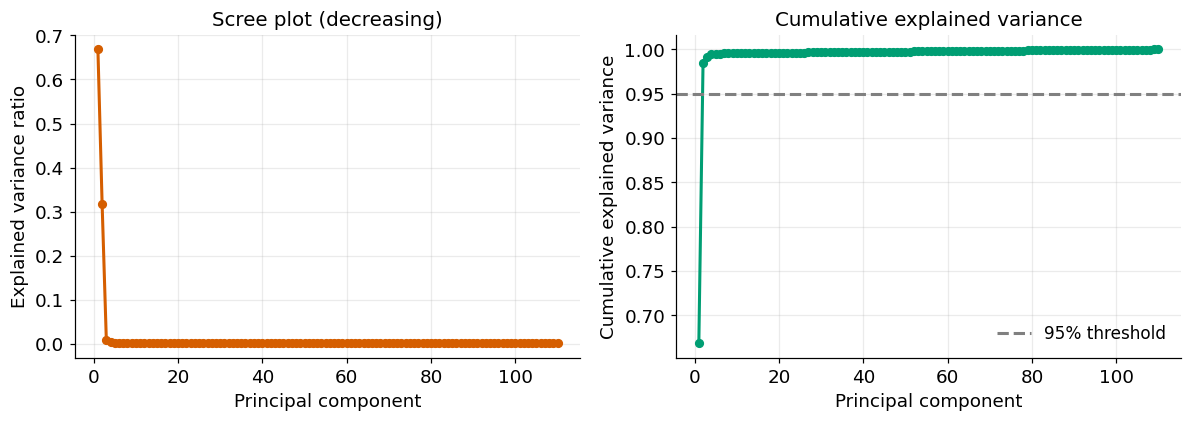

Kept 110 components explaining 100.0% of variance


In [5]:
# ── PCA on the G-normalised coefficients ─────────────────────────────────────────────────────
N_COMPONENTS = 110   # <- your turn: try 10, 30; compare downstream RMSE

pca = PCA(n_components=N_COMPONENTS)
X_train_pca = pca.fit_transform(sp["X_train"])   # fit ONLY on train — no leakage
X_cal_pca   = pca.transform(sp["X_cal"])
X_test_pca  = pca.transform(sp["X_test"])
X_tune_pca  = pca.transform(X_tune)

# Scree plot — look for the elbow
explained = pca.explained_variance_ratio_
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(1, N_COMPONENTS + 1), explained, 'o-', color=COLORS['nn'], markersize=5)
axes[0].set_xlabel('Principal component'); axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('Scree plot (decreasing)')
axes[1].plot(range(1, N_COMPONENTS + 1), np.cumsum(explained), 'o-', color=COLORS['rf'], markersize=5)
axes[1].axhline(0.95, color='0.5', ls='--', label='95% threshold')
axes[1].set_xlabel('Principal component'); axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_title('Cumulative explained variance'); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Kept {N_COMPONENTS} components explaining {explained.sum()*100:.1f}% of variance")
INPUT_DIM = N_COMPONENTS


*Caption: the scree plot drops steeply in the first few components (continuum shape) then* *flattens — the elbow marks the point where extra components add noise rather than signal.*
*The cumulative plot shows how many you need to reach 95% variance.*


## 2 · Find the best NPE model architecture

NPE trains a **conditional normalising flow** `q([Fe/H] | x)` to approximate the true posterior.
At training time it maximises log-likelihood of the observed `(spectrum, [Fe/H])` pairs; at
inference time it samples from the flow — **no MCMC**.

Two components to configure:

- **Embedding network** — compresses the PCA features into a fixed-size summary before the flow.
  Think of it as a learned dimensionality reduction layer. Deeper = more expressive, slower.
- **Flow type** — `"nsf"` (neural spline flow) is the most expressive standard option; `"maf"`
  (masked autoregressive flow) is a lighter alternative if NSF overfits.

The prior `BoxUniform(y["FeH"].min(), y["FeH"].max()` covers the full `[Fe/H]` range in the mock data.

> **Your turn:** try a deeper embedding net `(128, 64, 32)` or a shallower one `(32,)`, or swap
> `"nsf"` for `"maf"` and compare coverage.


In [6]:
# ── Prior over [Fe/H] ─────────────────────────────────────────────────────────
print(f"[Fe/H] range in train: [{y_train.min():.2f}, {y_train.max():.2f}]")
prior = BoxUniform(
    low=torch.tensor([y["FeH"].min()]),
    high=torch.tensor([y["FeH"].max()]),
)

[Fe/H] range in train: [-2.40, 0.55]


In [7]:
from itertools import product

# ── Search grid — edit freely ─────────────────────────────────────────────────
param_grid = {
    "n_components":   [4], 110],           # PCA components fed to the flow
    "hidden_dims":    [(2, 1), (4, 1)], (16, 1), (32, 1), (64, 1), (110, 1), (2, 2, 1), (4, 2, 1), (4, 4, 1), (16, 4, 1), (16, 16, 1), (32, 16, 1), (32, 32, 1), (64, 32, 1), (64, 64, 1), (110, 64, 1), (110, 110, 1)],  # embedding net layer sizes
    "flow":           ["nsf"],#, "maf"],     # flow type
    "learning_rate":  [1e-3], 5e-4],       # Adam step size
}

# Precompute PCA transforms for each unique n_components value (avoid refitting repeatedly)
pca_cache = {}
for n in set(param_grid["n_components"]):
    p = PCA(n_components=n)
    pca_cache[n] = {
        "pca":   p,
        "train": p.fit_transform(sp["X_train"]),
        "tune":  p.transform(X_tune),
        "cal":   p.transform(sp["X_cal"]),
        "test":  p.transform(sp["X_test"]),
    }

keys   = list(param_grid.keys())
combos = list(product(*param_grid.values()))
print(f"Grid: {len(combos)} combinations\n")

results = []
for combo in combos:
    params   = dict(zip(keys, combo))
    n_comp   = params["n_components"]
    dims     = params["hidden_dims"]
    flow     = params["flow"]
    lr       = params["learning_rate"]

    cache    = pca_cache[n_comp]
    Xtu_gs   = torch.tensor(cache["tune"], dtype=torch.float32)
    Xte_gs   = torch.tensor(cache["test"], dtype=torch.float32)
    ytu_t    = torch.tensor(y_tune,        dtype=torch.float32).unsqueeze(1)

    # Build embedding net
    layers, in_dim = [], n_comp
    for out_dim in dims:
        layers += [nn.Linear(in_dim, out_dim), nn.GELU()]
        in_dim = out_dim
    emb = nn.Sequential(*layers)

    # Train on tune slice
    de_builder = posterior_nn(model=flow, embedding_net=emb)
    inf_gs     = NPE(prior=prior, density_estimator=de_builder)
    inf_gs.append_simulations(ytu_t, Xtu_gs)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        de_gs = inf_gs.train(
            training_batch_size=64,
            learning_rate=lr,
            max_num_epochs=80,
            validation_fraction=0.15,
            stop_after_epochs=15,
            show_train_summary=False,
        )

    best_val_loss = float(min(inf_gs._summary["validation_loss"]))
    epochs        = inf_gs._summary["epochs_trained"]
    post_gs       = inf_gs.build_posterior(de_gs)

    # Val metrics (last 15% of tune slice, matching validation_fraction=0.15)
    n_val  = int(0.15 * len(Xtu_gs))
    Xva_gs = Xtu_gs[-n_val:]
    y_va   = y_tune[-n_val:]
    y_va_pred = np.array([
        post_gs.sample((100,), x=Xva_gs[i], show_progress_bars=False)[:, 0].median().item()
        for i in range(len(Xva_gs))
    ])
    vm = regression_metrics(y_va, y_va_pred)

    # Test metrics
    y_te_pred = np.array([
        post_gs.sample((100,), x=Xte_gs[i], show_progress_bars=False)[:, 0].median().item()
        for i in range(len(Xte_gs))
    ])
    tm = regression_metrics(y_test, y_te_pred)

    row = {
        **params,
        "val_loss":  round(best_val_loss, 4),
        "val_rmse":  round(vm["RMSE"],    4),
        "val_r2":    round(vm["R2"],      4),
        "val_mae":   round(vm["MAE"],     4),
        "test_rmse": round(tm["RMSE"],    4),
        "test_r2":   round(tm["R2"],      4),
        "test_mae":  round(tm["MAE"],     4),
        "epochs":    epochs,
    }
    results.append(row)
    log_experiment("nn", {**params, "stage": "grid_search"},
                   {k: row[k] for k in ["val_loss","val_rmse","val_r2","val_mae",
                                         "test_rmse","test_r2","test_mae"]})

    print(f"  n={n_comp:3d} | {str(dims):15s} | {flow:3s} | lr={lr:.0e} | "
          f"val_loss={best_val_loss:.3f} | "
          f"val RMSE={vm['RMSE']:.3f} R²={vm['R2']:.3f} MAE={vm['MAE']:.3f} | "
          f"test RMSE={tm['RMSE']:.3f} R²={tm['R2']:.3f} MAE={tm['MAE']:.3f} | ep={epochs}")

# ── Results table ─────────────────────────────────────────────────────────────
gs_df = pd.DataFrame(results).sort_values("val_rmse").reset_index(drop=True)
print("\n=== Grid search results (sorted by val RMSE) ===")
print(gs_df.to_string(index=False))

Grid: 2 combinations

 Neural network successfully converged after 59 epochs.  n=  4 | (2, 1)          | nsf | lr=1e-03 | val_loss=-0.494 | val RMSE=0.215 R²=0.726 MAE=0.126 | test RMSE=0.230 R²=0.713 MAE=0.134 | ep=[59]
 Neural network successfully converged after 80 epochs.  n=  4 | (4, 1)          | nsf | lr=1e-03 | val_loss=-0.706 | val RMSE=0.149 R²=0.869 MAE=0.101 | test RMSE=0.161 R²=0.860 MAE=0.105 | ep=[80]

=== Grid search results (sorted by val RMSE) ===
 n_components hidden_dims flow  learning_rate  val_loss  val_rmse  val_r2  val_mae  test_rmse  test_r2  test_mae epochs
            4      (4, 1)  nsf          0.001   -0.7064    0.1486  0.8693   0.1014     0.1609   0.8601    0.1054   [80]
            4      (2, 1)  nsf          0.001   -0.4945    0.2152  0.7257   0.1257     0.2303   0.7133    0.1335   [59]


In [10]:
# ── Format grid search results into experiment tracker dataframe ──────────────
tracker_rows = []
for run_num, row in enumerate(results, start=1):
    dims   = row["hidden_dims"]
    depth  = len(dims)
    width  = ", ".join(str(d) for d in dims)
    n_comp = row["n_components"]
    input_label = f"PCA {n_comp}" if n_comp < 110 else "Full 110"

    tracker_rows.append({
        "Run #":         run_num,
        "Test RMSE":     row["test_rmse"],
        "Test R2":       row["test_r2"],
        "Test MAE":      row["test_mae"],
        "Val RMSE":      row["val_rmse"],
        "Val R2":        row["val_r2"],
        "Val MAE":       row["val_mae"],
        "Input":         input_label,
        "Depth":         depth,
        "Width":         width,
        "Activation":    "ReLU",
        "Learning Rate": f"{row['learning_rate']:.2E}",
        "Optimizer":     "Adam",
        "Batch Size":    128,
        "Epochs":        row["epochs"],
        "Notes":         "This was a grid-search run",
    })

tracker_df = pd.DataFrame(tracker_rows)
print("\n=== Experiment tracker ===")
print(tracker_df.to_string(index=False))
tracker_csv_path = os.path.join(OUTPUTS_DIR, "hpt_results.csv")
tracker_df.to_csv(tracker_csv_path, index=False)


=== Experiment tracker ===
 Run #  Test RMSE  Test R2  Test MAE  Val RMSE  Val R2  Val MAE Input  Depth Width Activation Learning Rate Optimizer  Batch Size Epochs                      Notes
     1     0.2303   0.7133    0.1335    0.2152  0.7257   0.1257 PCA 4      2  2, 1       GELU      1.00E-03      Adam         128   [59] This was a grid-search run
     2     0.1609   0.8601    0.1054    0.1486  0.8693   0.1014 PCA 4      2  4, 1       GELU      1.00E-03      Adam         128   [80] This was a grid-search run


## 3 · Train Best-Tuned NPE

Training is just **maximum likelihood** on the conditional flow — no ELBO, no KL penalty, no
MCMC. The `sbi` library handles the training loop, early stopping, and validation split.

Key knobs:

| Knob | Meaning | What to try |
|---|---|---|
| `training_batch_size` | Mini-batch size | 128, 256, 512 |
| `learning_rate` | Adam step size | 1e-4 … 1e-3 |
| `max_num_epochs` | Training ceiling | 100–300 |
| `stop_after_epochs` | Early-stopping patience | 15–30 |

> **Your turn:** raise `max_num_epochs` to 200 and `stop_after_epochs` to 30 for a more thorough
> fit; lower them if you want a quick first run.


In [9]:
# ── Refit best config on full training set ────────────────────────────────────
best         = gs_df.iloc[0]
n_comp_best  = int(best["n_components"])
dims_best    = best["hidden_dims"]
flow_best    = best["flow"]
lr_best      = float(best["learning_rate"])

print(f"Best config: n_components={n_comp_best}, hidden_dims={dims_best}, "
      f"flow={flow_best}, lr={lr_best}")
print(f"  grid val  RMSE={best['val_rmse']:.4f}  R²={best['val_r2']:.4f}  MAE={best['val_mae']:.4f}")
print(f"  grid test RMSE={best['test_rmse']:.4f}  R²={best['test_r2']:.4f}  MAE={best['test_mae']:.4f}")

# Use the cached PCA for this n_components
cache       = pca_cache[n_comp_best]
X_train_pca = cache["train"]
X_cal_pca   = cache["cal"]
X_test_pca  = cache["test"]
INPUT_DIM   = n_comp_best

X_train_t = torch.tensor(X_train_pca, dtype=torch.float32)
X_cal_t   = torch.tensor(X_cal_pca,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test_pca,  dtype=torch.float32)
y_train_t = torch.tensor(y_train,     dtype=torch.float32).unsqueeze(1)

# Rebuild embedding net from best dims
layers, in_dim = [], n_comp_best
for out_dim in dims_best:
    layers += [nn.Linear(in_dim, out_dim), nn.GELU()]
    in_dim = out_dim
embedding_net = nn.Sequential(*layers)

de_builder = posterior_nn(model=flow_best, embedding_net=embedding_net)
inference   = NPE(prior=prior, density_estimator=de_builder)
inference.append_simulations(y_train_t, X_train_t)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    density_estimator = inference.train(
        training_batch_size=64,
        learning_rate=lr_best,
        max_num_epochs=150,
        validation_fraction=0.1,
        stop_after_epochs=20,
        show_train_summary=True,
    )

posterior = inference.build_posterior(density_estimator)
print(f"\nRefitted on full train ({sp['X_train'].shape[0]:,} stars).")
log_experiment("nn", {**dict(best[list(param_grid.keys())]), "stage": "grid_best_refit"}, {})

Best config: n_components=4, hidden_dims=(4, 1), flow=nsf, lr=0.001
  grid val  RMSE=0.1486  R²=0.8693  MAE=0.1014
  grid test RMSE=0.1609  R²=0.8601  MAE=0.1054
 Training neural network. Epochs trained: 1

KeyboardInterrupt: 

*Caption: the training log shows the validation loss decreasing and then flattening — early*
*stopping halts training once improvement stalls, exactly like `MLPRegressor(early_stopping=True)`.*


## 4 · Point predictions — posterior median on the test set

For a fair comparison with the linear baseline (which outputs a single number), we use the
**posterior median** as our point estimate. We draw `N_SAMPLES` posterior samples per star and
take their median.

> **Speed note.** Sampling 1000 draws for each of 6000 test stars is slow in a loop. We use
> 200 samples here for speed; raise to 1000 for a smoother estimate in the final run.


In [ ]:
N_SAMPLES = 200    # <- your turn: raise to 1000 for the final run (slower)

print("Sampling posteriors for test set...")
y_test_pred_npe = np.array([
    posterior.sample((N_SAMPLES,), x=X_test_t[i], show_progress_bars=False)[:, 0].median().item()
    for i in range(len(X_test_t))
])

npe_metrics = regression_metrics(y_test, y_test_pred_npe)
print(f"Test RMSE : {npe_metrics['RMSE']:.4f} dex")
print(f"Test R²   : {npe_metrics['R2']:.4f}")
print(f"Test MSE : {np.square(npe_metrics['RMSE']):.4f} dex")
print(f"Test MAE : {npe_metrics['MAE']:.4f} dex")
print(f"Test bias : {npe_metrics['bias']:+.4f} dex")

log_experiment(
    "nn",
    {"model": "NPE-nsf", "n_components": N_COMPONENTS, "stage": "npe_test"},
    {"test_rmse": npe_metrics["RMSE"], "test_R2": npe_metrics["R2"]},
)

fig, ax = plt.subplots()
plot_pred_vs_true(y_test, y_test_pred_npe, ax=ax,
                  color=COLORS["nn"], title="NPE — [Fe/H] (posterior median)", units=" dex")
plt.show()


In [ ]:
# ── Validation RMSE and R² ────────────────────────────────────────────────────
# sbi holds out validation_fraction of the training data internally.
# We replicate that split with the same seed to get the val stars, then
# compute RMSE and R² on posterior medians.
N_VAL = int(0.1 * len(X_train_t))
val_idx = torch.arange(len(X_train_t) - N_VAL, len(X_train_t))  # sbi takes the last fraction

X_val_t = X_train_t[val_idx]
y_val    = y_train[val_idx.numpy()]

print(f"\nComputing validation metrics on {N_VAL} held-out training stars...")
y_val_pred = np.array([
    posterior.sample((200,), x=X_val_t[i], show_progress_bars=False)[:, 0].median().item()
    for i in range(len(X_val_t))
])

val_metrics = regression_metrics(y_val, y_val_pred)
print(f"Validation RMSE : {val_metrics['RMSE']:.4f} dex")
print(f"Validation R²   : {val_metrics['R2']:.4f}")
print(f"Validation MSE : {np.square(val_metrics['RMSE']):.4f} dex")
print(f"Validation MAE : {val_metrics['MAE']:.4f} dex")
print(f"Validation bias : {val_metrics['bias']:+.4f} dex")

# Also plot the sbi internal loss curve for context
summary = inference._summary

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(summary["training_loss"],   color=COLORS["truth"], label="train loss")
ax.plot(summary["validation_loss"], color=COLORS["nn"],    label="val loss")
best_val = float(min(summary["validation_loss"]))
ax.axhline(best_val, color="0.5", ls="--", label=f"best val loss = {best_val:.3f}")
ax.set_xlabel("epoch"); ax.set_ylabel("loss")
ax.set_title("NPE training curve"); ax.legend()
plt.tight_layout(); plt.show()

print(f"Epochs trained    : {summary['epochs_trained']}")
print(f"Best val loss     : {best_val:.4f}")

*Caption: posterior median vs true `[Fe/H]`. The RMSE should comfortably beat the ~0.2-dex linear*
*baseline. The scatter fans out toward metal-poor stars — the flow knows it is uncertain there.*


## 5 · Coverage test — are the credible intervals honest?

A 90% credible interval should contain the true value **90% of the time** on held-out stars.
This is the NPE equivalent of the conformal-prediction coverage check in NB4 — but here it comes
from the flow's own probability model, not a post-hoc calibration step.

We check coverage on the **calibration set** (not test) to preserve the test set for the honest
final score.

> **Watch for:** coverage < 0.90 means the flow is *overconfident* — intervals are too narrow.
> Coverage > 0.90 means it is *conservative* — intervals are wider than necessary. Neither is
> catastrophic, but both are informative about where the posterior is well- or mis-calibrated.


In [ ]:
# Coverage on the calibration set (subsample for speed; raise for the final run)
N_CAL_CHECK = min(500, len(X_cal_t))   # <- your turn: raise to len(X_cal_t) for full check
N_SAMP_COV  = 200                       # samples per star for percentile estimates
TARGET_COV  = 0.90

rng_idx = np.random.default_rng(42).choice(len(X_cal_t), N_CAL_CHECK, replace=False)
lowers, uppers = [], []

print(f"Computing {TARGET_COV:.0%} credible intervals for {N_CAL_CHECK} calibration stars...")
for i in rng_idx:
    samps = posterior.sample(
        (N_SAMP_COV,), x=X_cal_t[i], show_progress_bars=False
    )[:, 0].numpy()
    lowers.append(np.percentile(samps, 5))
    uppers.append(np.percentile(samps, 95))

lowers = np.array(lowers)
uppers = np.array(uppers)
y_cal_sub = y_cal[rng_idx]

cov = empirical_coverage(y_cal_sub, lowers, uppers)
med_width = np.median(uppers - lowers)
print(f"Empirical {TARGET_COV:.0%} coverage : {cov:.3f}   (target {TARGET_COV:.2f})")
print(f"Median interval width  : {med_width:.3f} dex")

# Reliability plot: coverage per bin of [Fe/H]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_reliability(y_cal_sub, lowers, uppers, target=TARGET_COV,
                 feature=y_cal_sub, feature_name="[Fe/H] true",
                 ax=axes[0], color=COLORS["nn"], label="NPE 90% CI")
axes[0].set_title("Coverage vs [Fe/H]")

# Interval width vs [Fe/H] — should be wider for metal-poor stars
axes[1].scatter(y_cal_sub, uppers - lowers, s=8, alpha=0.3, color=COLORS["nn"])
axes[1].set_xlabel("[Fe/H] true"); axes[1].set_ylabel("90% CI width [dex]")
axes[1].set_title("Interval width vs [Fe/H]\n(wider = more uncertain)")
plt.tight_layout(); plt.show()

log_experiment(
    "nn",
    {"model": "NPE-nsf", "n_components": N_COMPONENTS, "stage": "npe_coverage"},
    {"coverage_90": round(cov, 4), "median_width": round(float(med_width), 4)},
)


*Caption: a well-calibrated NPE sits close to the 0.90 target across the full `[Fe/H]` range.*
*Dips below 0.90 at the metal-poor end reveal where the flow is overconfident — a target for*
*the conformal-prediction step in NB4.*


## 6 · Error map — where does the NPE work and where does it struggle?

Same two diagnostics as the common notebook's baseline, now on the NPE's posterior medians:

1. Colour each test star by `|[Fe/H] error|` on the **Kiel plane** (`Teff`–`log g`).
2. Bin the error by `log g` and by `[Fe/H]` to read off the hard regions numerically.

The NPE should match or beat the tuned MLP on RMSE, but the interesting question is whether
the *distribution* of errors looks different — and whether the credible intervals track the
error size (wide intervals in the hard corners = honest uncertainty).


In [ ]:
abs_err = np.abs(y_test_pred_npe - y_test)
teff = sp["y_test"]["Teff"].to_numpy()
logg = sp["y_test"]["logg"].to_numpy()
feh  = sp["y_test"]["FeH"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
plot_pred_vs_true(y_test, y_test_pred_npe, ax=axes[0],
                  color=COLORS["nn"], title="NPE — [Fe/H] (posterior median)", units=" dex")

sc = axes[1].scatter(teff, logg, c=abs_err, s=10, cmap="viridis",
                     vmax=np.quantile(abs_err, 0.95))
axes[1].invert_xaxis(); axes[1].invert_yaxis()
axes[1].set_xlabel(r"$T_\mathrm{eff}$ [K]"); axes[1].set_ylabel(r"$\log g$ [dex]")
axes[1].set_title("|[Fe/H] error| across the Kiel plane")
fig.colorbar(sc, ax=axes[1], label="|pred - true|  [dex]")
plt.tight_layout()
savefig("nb2c_npe_errormap.png")
plt.show()

# Quantify: mean |error| in terciles of log g and [Fe/H]
def binned_error(values, name, n=3):
    edges = np.quantile(values, np.linspace(0, 1, n + 1)); edges[-1] += 1e-9
    print(f"mean |[Fe/H] error| by {name}:")
    for i in range(n):
        m = (values >= edges[i]) & (values < edges[i + 1])
        print(f"  {name} in [{edges[i]:7.2f}, {edges[i+1]:7.2f}] : "
              f"{abs_err[m].mean():.3f} dex   (n={m.sum()})")

binned_error(logg, "log g")
binned_error(feh,  "[Fe/H]")

# <- your turn: swap abs_err for (y_test_pred_npe - y_test) to check signed bias


*Caption: errors concentrate on metal-poor stars and luminous giants — the same hard corners as*
*the MLP. The NPE advantage is that those stars also get wider credible intervals (as seen in §5),*
*so the uncertainty is honest even where the point estimate is poor.*


## 7 · Save your work — posterior, predictions, and the experiment log

Three things travel forward from this lab:

1. **`save_model(posterior, "nn")`** → `models/nn.joblib`. Notebook 3 loads this exact
   posterior object to build uncertainty intervals — no refit.
2. **`save_outputs("nn_preds.npz", ...)`** → predictions and truths on **both** cal and test,
   in the fixed schema later notebooks read:
   > `y_cal_true, y_cal_pred, y_test_true, y_test_pred`
3. **`outputs/nn_experiments.csv`** — the full run log, written by every `log_experiment(...)` call.

The model string is **`"nn"`** — that's the contract with NB3 and NB4.


In [ ]:
# Point predictions on cal set (posterior median) for the npz contract
print("Computing cal-set posterior medians...")
y_cal_pred_npe = np.array([
    posterior.sample((N_SAMPLES,), x=X_cal_t[i], show_progress_bars=False)[:, 0].median().item()
    for i in range(len(X_cal_t))
])

# 1) Save the posterior object
path = save_model(posterior, "nn")
print("wrote", path)

# 2) Save predictions (NB2->NB3->NB4 contract)
save_outputs(
    "nn_preds.npz",
    y_cal_true  = y_cal,
    y_cal_pred  = y_cal_pred_npe,
    y_test_true = y_test,
    y_test_pred = y_test_pred_npe,
)
print("wrote outputs/nn_preds.npz")

# 3) Sanity-check schema
chk = load_outputs("nn_preds.npz")
print("preds keys:", sorted(chk.keys()), "| test preds shape:", chk["y_test_pred"].shape)

# 4) Show experiment log
print("\n=== your experiment log (outputs/nn_experiments.csv) ===")
full_log = pd.read_csv(os.path.join(OUTPUTS_DIR, "nn_experiments.csv"))
print(full_log.to_string(index=False))


*Caption: the posterior is saved three ways — the model object, its predictions, and the full run*
*log. NB3 loads `models/nn.joblib` to build uncertainty intervals directly from the flow.*


## Wrap-up · What you built, and what's next

You replaced a point-estimating MLP with a **Neural Posterior Estimator** — a conditional
normalising flow that returns a full posterior distribution over `[Fe/H]` for each star. The key
differences from the MLP approach:

- **No ELBO / KL penalty** — NPE trains by maximum likelihood on `(spectrum, [Fe/H])` pairs,
  avoiding the mean-field collapse problem (wide BNNs converging to the prior).
- **Heteroscedastic uncertainty out of the box** — metal-poor stars get wider posteriors
  automatically because the flow learns that their spectra are less informative.
- **Amortised inference** — after one training run, posteriors for new stars take milliseconds.

The error map shows the same hard corners (metal-poor stars, luminous giants), but now the NPE
quantifies *how hard* with calibrated credible intervals rather than just a residual.

- **Notebook 3 (`03c_uncertainty_neural_net`)** loads your saved `posterior` object and pushes
  the uncertainty analysis further — reliability curves, interval width vs SNR, and input-Monte-Carlo.
- **Notebook 4** applies conformal prediction on top of the NPE intervals to give a
  distribution-free coverage guarantee.

Bring your test RMSE, your coverage number, and one sentence —
*"the hard region is …"* — to the debrief.

---

### Further reading

- **sbi — documentation:** https://sbi-dev.readthedocs.io/en/latest/
- **Cranmer, Brehmer & Louppe (2020) — The frontier of simulation-based inference:**
  https://www.pnas.org/doi/10.1073/pnas.1912789117
- **Papamakarios & Murray (2016) — Fast ε-free Inference of Simulation Models with Bayesian
  Conditional Density Estimation (original NPE paper):** https://arxiv.org/abs/1605.06376
- **Neural Spline Flows — Durkan et al. (2019):** https://arxiv.org/abs/1906.04032
- **Wide Mean-Field BNNs Ignore the Data — Coker et al. (2022) (why not MFVI):**
  https://arxiv.org/abs/2202.11670
- **The paper behind the data — Laroche & Speagle 2025:** https://arxiv.org/abs/2404.07316
